# 2η Εργασία – Μέρος Α: LSTM Forecasting

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# MPS backend
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


# Load Data

In [3]:
df = pd.read_csv("dataset.csv")

STATE_COLS = ["u1", "u2", "u3", "u4", "u5",
              "v1", "v2", "v3", "v4", "v5"]

train_df = df[df["split"] == "train"]
test_df  = df[df["split"] == "test"]

# Make every trajectory as (X, F):
#   X : (1001, 10)  includes the STATE_COLS
#   F : (1001,)     forcing at the top node
def load_trajectories(df_split):
    trajs = []
    for tid in sorted(df_split["traj_id"].unique()):
        traj = df_split[df_split["traj_id"] == tid].sort_values("t")
        X = traj[STATE_COLS].values.astype(np.float32)      # (1001, 10)
        F = traj["F_top"].values.astype(np.float32)         # (1001,)
        trajs.append((X, F))
    return trajs

train_trajs = load_trajectories(train_df) # list with tuple (X, F) 
test_trajs  = load_trajectories(test_df) #         -//-

print(f"Train trajectories: {len(train_trajs)}")
print(f"Test  trajectories: {len(test_trajs)}")
print(f"Shape of one X: {train_trajs[0][0].shape}")
print(f"Shape of one F: {train_trajs[0][1].shape}")


Train trajectories: 60
Test  trajectories: 15
Shape of one X: (1001, 10)
Shape of one F: (1001,)


In [17]:
# Stack all the training states
all_X = np.vstack([X for X, F in train_trajs])   # (60*1001, 10)
all_F = np.concatenate([F for X, F in train_trajs])  # (60*1001,)

# Calculate mean and std on the training states only - Normalization Process
X_mean = all_X.mean(axis=0).astype(np.float32)
X_std  = all_X.std(axis=0).astype(np.float32)
X_std  = np.where(X_std < 1e-8, 1.0, X_std) 

F_mean = float(all_F.mean())
F_std  = float(all_F.std())

print("X_mean:", X_mean.round(4))
print("X_std:", X_std.round(4))
print("F_mean:", X_mean.round(4))
print("F_std: ", X_std.round(4))

X_mean: [ 1.e-04  2.e-04  3.e-04  5.e-04  6.e-04 -2.e-04 -3.e-04 -3.e-04 -3.e-04
 -2.e-04]
X_std: [0.0235 0.0429 0.0575 0.0688 0.0765 0.1022 0.1595 0.1728 0.1905 0.2226]
F_mean: [ 1.e-04  2.e-04  3.e-04  5.e-04  6.e-04 -2.e-04 -3.e-04 -3.e-04 -3.e-04
 -2.e-04]
F_std:  [0.0235 0.0429 0.0575 0.0688 0.0765 0.1022 0.1595 0.1728 0.1905 0.2226]


# Creating a custom Dataset

In [18]:
WINDOW_P = 20  # number of p states 

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories, window_p):
        self.samples = []  # list of (input, target) tuples

        for X, F in trajectories:
            # Normalization
            X_norm = (X - X_mean) / X_std          # (1001, 10)
            F_norm = (F - F_mean) / F_std           # (1001,)

            # state  + force into one array (1001, 11)
            XF = np.column_stack([X_norm, F_norm])  # (1001, 11)

            # Sliding window
            for start in range(len(XF) - window_p):
                end = start + window_p

                inp = XF[start:end]       # (p_state, 11) — input
                tgt = XF[end, :10]        # (10,)             — target: only state cols

                self.samples.append((
                    torch.tensor(inp, dtype=torch.float32),
                    torch.tensor(tgt, dtype=torch.float32)
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# Construction of datasets
train_dataset = TrajectoryDataset(train_trajs, WINDOW_P)
test_dataset  = TrajectoryDataset(test_trajs, WINDOW_P)

print(f"Train samples: {len(train_dataset)}")
print(f"Test  samples: {len(test_dataset)}")

# Check one sample
inp, tgt = train_dataset[0]
print(f"\nInput shape : {inp.shape}   (window_p=20, features=11)")
print(f"Target shape: {tgt.shape}  (next state: 10 values)")


Train samples: 58860
Test  samples: 14715

Input shape : torch.Size([20, 11])   (window_p=20, features=11)
Target shape: torch.Size([10])  (next state: 10 values)


# Iterate through the DataLoader

In [19]:
BATCH_SIZE = 256 # power of two 

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True    # shuffle samples in every epoch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False   # no need for shuffling in test set
)

# Check one batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch input shape : {X_batch.shape}  (batch, window_p, features)")
print(f"Batch target shape: {y_batch.shape}  (batch, 10)")


Batch input shape : torch.Size([256, 20, 11])  (batch, window_p, features)
Batch target shape: torch.Size([256, 10])  (batch, 10)


# Built LSTM model

In [20]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()

        # LSTM layer
        # input_size  : features in each time step (11)
        # hidden_size : hidden state size
        # num_layers  : LSTM layers stacked

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True
        )

        # Linear layer: hidden_size → output_size (Applies an affine linear transformation to the incoming data)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        # lstm_out: (batch, seq_len, hidden_size)
        # lstm_out[:, -1, :] shape: (batch, hidden_size)
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :] # hidden state at the final timestep

        # out shape: (batch, output_size)
        out = self.linear(last_output)

        return out


# LSTM Paremeters
INPUT_SIZE  = 11   # 10 state cols + 1 force node
HIDDEN_SIZE = 64
NUM_LAYERS  = 1
OUTPUT_SIZE = 10   # next state

model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
model = model.to(device)

print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")


LSTMModel(
  (lstm): LSTM(11, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=10, bias=True)
)

Total Parameters: 20,362


# Training Loop

Η κλασική PyTorch training loop:
```
for epoch in epochs:
    for batch in train_loader:
        optimizer.zero_grad()   # 1. μηδένισε gradients
        pred = model(X)         # 2. forward pass
        loss = loss_fn(pred, y) # 3. υπολόγισε loss
        loss.backward()         # 4. backward pass (autograd)
        optimizer.step()        # 5. ενημέρωσε βάρη
```

Δες: https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html


In [27]:
# # Loss function: MSE 
# loss_fn   = nn.MSELoss()

# # Optimizer: Adam 
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# EPOCHS = 100

# train_losses = []
# test_losses  = []

# for epoch in range(EPOCHS):

#     # Training 
#     model.train()  
#     epoch_train_loss = 0.0

#     for X_batch, y_batch in train_loader:
#         X_batch = X_batch.to(device)
#         y_batch = y_batch.to(device)

#         optimizer.zero_grad()              
#         pred = model(X_batch)              
#         loss = loss_fn(pred, y_batch)      
#         loss.backward()                    
#         optimizer.step()                  

#         epoch_train_loss += loss.item()

#     avg_train_loss = epoch_train_loss / len(train_loader)

#     # Evaluation 
#     model.eval()   
#     epoch_test_loss = 0.0

#     with torch.no_grad():   
#         for X_batch, y_batch in test_loader:
#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device)

#             pred = model(X_batch)
#             loss = loss_fn(pred, y_batch)
#             epoch_test_loss += loss.item()

#     avg_test_loss = epoch_test_loss / len(test_loader)

#     train_losses.append(avg_train_loss)
#     test_losses.append(avg_test_loss)

#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
#               f"Train Loss: {avg_train_loss:.3e} | "
#               f"Test Loss:  {avg_test_loss:.3e}")


In [25]:
# Loss function: MSE
loss_fn   = nn.MSELoss()

# Optimizer: Adam
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Learning rate scheduler — reduces lr when test loss plateaus
# factor=0.5  -> lr_new = lr_old * 0.5
# patience=5  -> wait 5 epochs with no improvement before reducing lr
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

EPOCHS = 100

train_losses = []
test_losses  = []

# Early stopping / checkpointing state
best_test_loss = float('inf')
best_epoch     = -1
patience_es    = 15          # epochs with no improvement before stopping entirely
epochs_no_improve = 0
best_model_state = None

for epoch in range(EPOCHS):

    # Training 
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)

    # Evaluation 
    model.eval()
    epoch_test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            epoch_test_loss += loss.item()

    avg_test_loss = epoch_test_loss / len(test_loader)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    # Scheduler step (based on test loss)
    scheduler.step(avg_test_loss)

    # Checkpoint if improved
    if avg_test_loss < best_test_loss:
        best_test_loss   = avg_test_loss
        best_epoch       = epoch + 1
        epochs_no_improve = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]['lr']

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
                f"Train Loss: {avg_train_loss:.3e} | "
                f"Test Loss:  {avg_test_loss:.3e} | "
                f"LR: {current_lr:.2e} | "
                f"Best: {best_test_loss:.3e} @ epoch {best_epoch}")

    # Early stopping
    if epochs_no_improve >= patience_es:
        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no improvement for {patience_es} epochs)")
        break

# Load the BEST checkpoint, not the last one
model.load_state_dict(best_model_state)
print(f"\nLoaded best model from epoch {best_epoch} "
      f"(test loss = {best_test_loss:.3e})")

Epoch   1/100 | Train Loss: 8.258e-06 | Test Loss:  5.478e-07 | LR: 1.00e-03 | Best: 5.478e-07 @ epoch 1
Epoch   5/100 | Train Loss: 2.055e-06 | Test Loss:  1.511e-06 | LR: 1.00e-03 | Best: 3.113e-07 @ epoch 4
Epoch  10/100 | Train Loss: 5.413e-06 | Test Loss:  8.746e-07 | LR: 1.00e-03 | Best: 2.349e-07 @ epoch 8
Epoch  15/100 | Train Loss: 2.308e-07 | Test Loss:  9.368e-08 | LR: 5.00e-04 | Best: 9.368e-08 @ epoch 15
Epoch  20/100 | Train Loss: 2.058e-07 | Test Loss:  1.611e-07 | LR: 5.00e-04 | Best: 9.368e-08 @ epoch 15
Epoch  25/100 | Train Loss: 1.207e-07 | Test Loss:  9.089e-08 | LR: 2.50e-04 | Best: 8.437e-08 @ epoch 24
Epoch  30/100 | Train Loss: 2.002e-07 | Test Loss:  1.032e-07 | LR: 1.25e-04 | Best: 8.437e-08 @ epoch 24
Epoch  35/100 | Train Loss: 1.053e-07 | Test Loss:  8.695e-08 | LR: 1.25e-04 | Best: 7.717e-08 @ epoch 31
Epoch  40/100 | Train Loss: 8.319e-08 | Test Loss:  7.540e-08 | LR: 6.25e-05 | Best: 6.633e-08 @ epoch 39
Epoch  45/100 | Train Loss: 1.052e-07 | Test Loss

## Cell 8 – Learning Curves

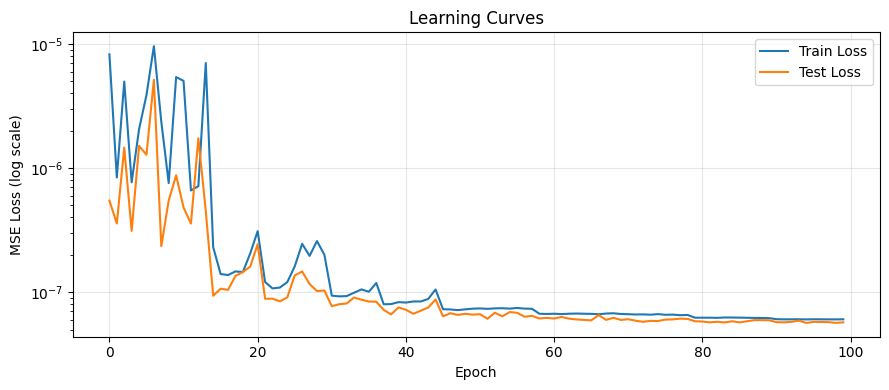

In [28]:
plt.figure(figsize=(9, 4))
plt.semilogy(train_losses, label="Train Loss")
plt.semilogy(test_losses,  label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("Learning Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# One-Step Ahead Prediction


In [100]:
def one_step_ahead(model, X, F):
    """
    X: (1001, 10) unnormalized state
    F: (1001,)    unnormalized force
    Returns: (981, 10) predictions in original scale
    """
    # Normalization
    X_norm = (X - X_mean) / X_std
    F_norm = (F - F_mean) / F_std
    XF = np.column_stack([X_norm, F_norm]).astype(np.float32)  # (1001, 11)

    
    windows = np.stack([XF[s:s+WINDOW_P] for s in range(len(XF)-WINDOW_P)])
    # windows shape: (981, 20, 11)

    model.eval()
    with torch.no_grad():
        inp  = torch.tensor(windows).to(device)
        pred = model(inp).cpu().numpy()   # (981, 10) — normalized

    # Denormalize
    return pred * X_std + X_mean


# Evaluation in one trajectory
X_test0, F_test0 = test_trajs[0]
preds_1step = one_step_ahead(model, X_test0, F_test0)
targets     = X_test0[WINDOW_P:]   # ground truth

rmse_per_dof = np.sqrt(np.mean((preds_1step - targets)**2, axis=0))
print("RMSE per DOF (one-step, test traj 0):")
for col, r in zip(STATE_COLS, rmse_per_dof):
    print(f"  {col}: {r:.4e}")


RMSE per DOF (one-step, test traj 0):
  u1: 1.7505e-06
  u2: 3.6877e-06
  u3: 2.8659e-06
  u4: 8.6909e-06
  u5: 7.2347e-06
  v1: 1.4853e-05
  v2: 2.5642e-05
  v3: 2.9410e-05
  v4: 3.0362e-05
  v5: 2.3505e-05


## Cell 10 – Autoregressive Rollout

Το μοντέλο τροφοδοτείται με τις **δικές του προβλέψεις** αντί για πραγματικά data.
Κάθε σφάλμα «μολύνει» την επόμενη πρόβλεψη.

Seed: τα πρώτα `p` πραγματικά βήματα από το dataset.


In [101]:
def autoregressive_rollout(model, X, F):
    """
    X: (1001, 10) unnormalized
    F: (1001,)    unnormalized
    Returns: (981, 10) predictions in original scale
    """
    X_norm = (X - X_mean) / X_std
    F_norm = (F - F_mean) / F_std

    # Buffer: ξεκινάμε με τα πρώτα p πραγματικά states
    buffer = X_norm[:WINDOW_P].astype(np.float32).copy()  # (p, 10)

    preds = []

    model.eval()
    with torch.no_grad():
        for step in range(len(X_norm) - WINDOW_P):
            # Παίρνουμε το παράθυρο F για αυτό το step
            F_window = F_norm[step:step+WINDOW_P].astype(np.float32)  # (p,)

            # Κατασκευή input: state buffer + force window
            inp = np.column_stack([buffer, F_window])    # (p, 11)
            inp_tensor = torch.tensor(inp).unsqueeze(0).to(device)  # (1, p, 11)

            # Πρόβλεψη επόμενου state
            pred = model(inp_tensor).cpu().numpy()[0]    # (10,)
            preds.append(pred)

            # Ενημέρωση buffer: βγάζουμε το παλαιότερο, βάζουμε την πρόβλεψη
            buffer[:-1] = buffer[1:]
            buffer[-1]  = pred

    preds = np.array(preds)           # (981, 10) — normalized
    return preds * X_std + X_mean     # denormalize


preds_auto = autoregressive_rollout(model, X_test0, F_test0)
rmse_auto  = np.sqrt(np.mean((preds_auto - targets)**2, axis=0))

print("RMSE ανά DOF (autoregressive, test traj 0):")
print(f"{'DOF':<6} | {'One-step':>10} | {'Autoregressive':>14}")
print("-" * 36)
for col, r1, ra in zip(STATE_COLS, rmse_per_dof, rmse_auto):
    print(f"{col:<6} | {r1:>10.3e} | {ra:>14.3e}")


RMSE ανά DOF (autoregressive, test traj 0):
DOF    |   One-step | Autoregressive
------------------------------------
u1     |  1.750e-06 |      5.639e-04
u2     |  3.688e-06 |      1.081e-03
u3     |  2.866e-06 |      1.507e-03
u4     |  8.691e-06 |      1.810e-03
u5     |  7.235e-06 |      1.966e-03
v1     |  1.485e-05 |      1.617e-03
v2     |  2.564e-05 |      3.082e-03
v3     |  2.941e-05 |      4.267e-03
v4     |  3.036e-05 |      5.111e-03
v5     |  2.351e-05 |      5.538e-03


## Cell 11 – Γραφήματα

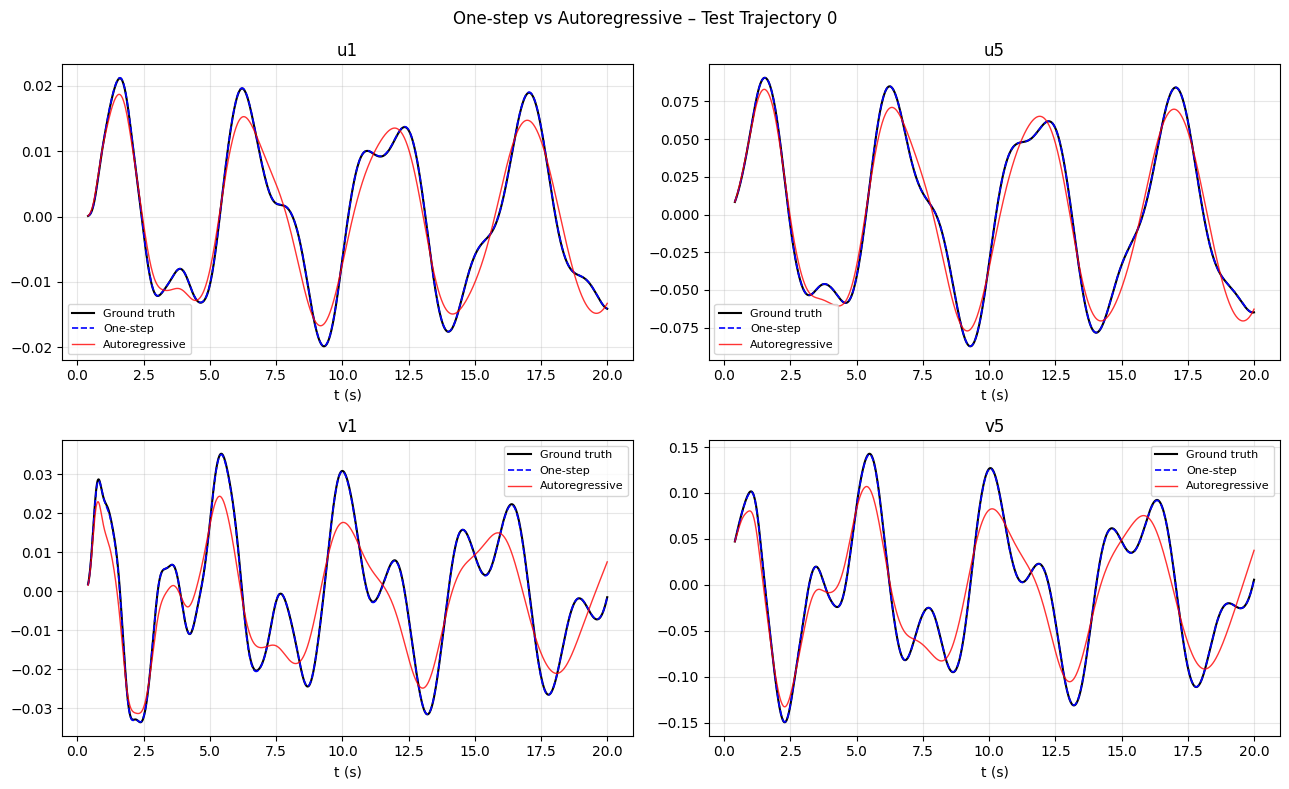

In [11]:
t_axis = np.arange(1001) * 0.02    # χρόνος σε seconds
t_pred = t_axis[WINDOW_SIZE:]      # από το 20ό βήμα και μετά

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("One-step vs Autoregressive – Test Trajectory 0", fontsize=12)

for ax, dof, label in zip(axes.flat,
                           [0, 4, 5, 9],
                           ["u1", "u5", "v1", "v5"]):
    ax.plot(t_pred, targets[:,dof],       "k-",  lw=1.5, label="Ground truth")
    ax.plot(t_pred, preds_1step[:,dof],   "b--", lw=1.2, label="One-step")
    ax.plot(t_pred, preds_auto[:,dof],    "r-",  lw=1.0, label="Autoregressive", alpha=0.8)
    ax.set_xlabel("t (s)")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Cell 12 – Συσσώρευση Σφάλματος στο Χρόνο

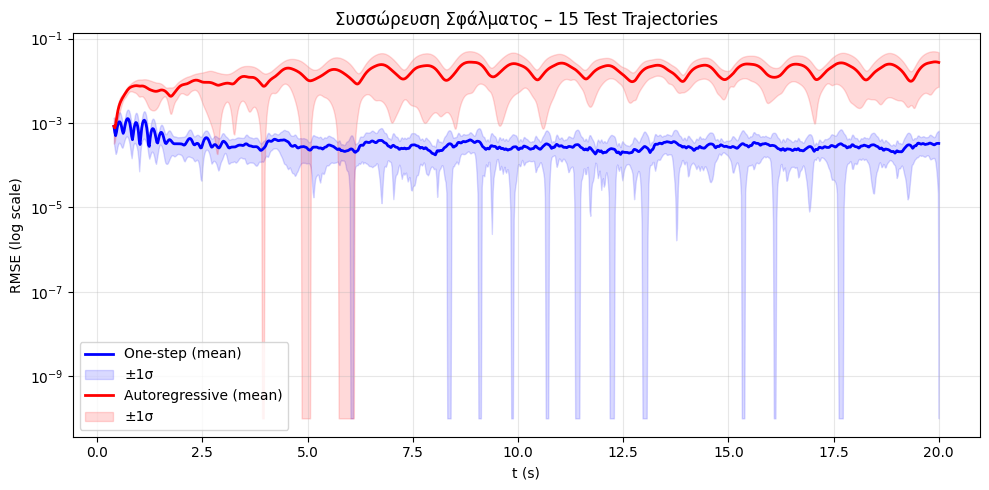

RMSE one-step   στο t=20s: 3.275e-04
RMSE autoregr.  στο t=20s: 2.716e-02


In [12]:
# Υπολογισμός RMSE σε κάθε timestep για όλες τις test τροχιές
all_err_1step = []
all_err_auto  = []

for X, F in test_trajs:
    p1  = one_step_ahead(model, X, F)
    par = autoregressive_rollout(model, X, F)
    tgt = X[WINDOW_SIZE:]

    # RMSE ανά timestep (μέσος πάνω από όλα τα DOFs)
    all_err_1step.append(np.sqrt(np.mean((p1  - tgt)**2, axis=1)))
    all_err_auto.append( np.sqrt(np.mean((par - tgt)**2, axis=1)))

all_err_1step = np.array(all_err_1step)   # (15, 981)
all_err_auto  = np.array(all_err_auto)    # (15, 981)

m1 = all_err_1step.mean(axis=0)
ma = all_err_auto.mean(axis=0)
s1 = all_err_1step.std(axis=0)
sa = all_err_auto.std(axis=0)

plt.figure(figsize=(10, 5))
plt.semilogy(t_pred, m1, "b-", lw=2, label="One-step (mean)")
plt.fill_between(t_pred, np.clip(m1-s1, 1e-10, None), m1+s1,
                 alpha=0.15, color="blue", label="±1σ")
plt.semilogy(t_pred, ma, "r-", lw=2, label="Autoregressive (mean)")
plt.fill_between(t_pred, np.clip(ma-sa, 1e-10, None), ma+sa,
                 alpha=0.15, color="red", label="±1σ")
plt.xlabel("t (s)")
plt.ylabel("RMSE (log scale)")
plt.title("Συσσώρευση Σφάλματος – 15 Test Trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"RMSE one-step   στο t=20s: {m1[-1]:.3e}")
print(f"RMSE autoregr.  στο t=20s: {ma[-1]:.3e}")


## Cell 13 – Αποθήκευση Μοντέλου

Αποθηκεύουμε τα βάρη του μοντέλου **και** τα normalization stats.
Τα stats χρειάζονται για να κάνουμε σωστό normalize/denormalize
όταν φορτώσουμε το μοντέλο στο Μέρος Β.

Δες: https://pytorch.org/tutorials/beginner/saving_loading_models.html


In [ ]:
# Αποθήκευση
torch.save({
    # Τα εκπαιδευμένα βάρη
    "model_state_dict": model.state_dict(),

    # Config για να ξέρουμε πώς να ξαναφτιάξουμε το μοντέλο
    "model_config": {
        "input_size":  INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers":  NUM_LAYERS,
        "output_size": OUTPUT_SIZE,
        "window_size": P_STATE,
    },

    # Normalization stats (απαραίτητα για inference)
    "X_mean": X_mean,
    "X_std":  X_std,
    "F_mean": F_mean,
    "F_std":  F_std,

}, "lstm_part_a.pth")

print("Saved: lstm_part_a.pth")

# ── Πώς να φορτώσεις το μοντέλο αργότερα ─────────────────────────────────────
checkpoint = torch.load("lstm_part_a.pth", map_location=device)

cfg = checkpoint["model_config"]
loaded_model = LSTMModel(
    input_size  = cfg["input_size"],
    hidden_size = cfg["hidden_size"],
    num_layers  = cfg["num_layers"],
    output_size = cfg["output_size"]
)
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print("Loaded model OK:", loaded_model)
